# Data Download and Pre-processing
In this notebook we obtain our data from the original source and carry out preliminary pre-processing for our project scope.

In [1]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shutil
import os
import polars as pl
from tqdm.notebook import tqdm

In [2]:
##### ‼️⚠️ THIS CELL MIGHT TAKE AROUND 15 MIN TO LOAD THE ENTIRE METADATA IF IT IS YOUR FIRST TIME RUNNING IT ‼️⚠️
##### ‼️⚠️ IT DOWNLOADS THE DATASET IN YOUR CACHE AND MAY TAKE SOME SPACE ‼️⚠️
DOWNLOAD = True
path = kagglehub.dataset_download("lokeshparab/gutenberg-books-and-metadata-2025")

print("Path to dataset files:", path)

Path to dataset files: /Users/ngocdoan/.cache/kagglehub/datasets/lokeshparab/gutenberg-books-and-metadata-2025/versions/4


In [3]:
total, used, free = shutil.disk_usage(os.path.expanduser("~/.cache/kagglehub"))
print(f"Total cache: {total / 1024**2:.2f} MB")
print(f"Cache used: {used / 1024**2:.2f} MB = {100 * used / total:.2f} %")
print(f"Free left: {free / 1024**2:.2f} MB = {100 * free / total:.2f} %")

Total cache: 233752.44 MB
Cache used: 217185.85 MB = 92.91 %
Free left: 16566.59 MB = 7.09 %


In [4]:
import os

total = 0
for dirpath, dirnames, filenames in os.walk(path):
    for f in filenames:
        fp = os.path.join(dirpath, f)
        total += os.path.getsize(fp)

print(f"Folder size: {total / 1024**3:.2f} GB")

Folder size: 28.86 GB


In [5]:
file_count = sum(len(files) for _, _, files in os.walk(path + "/books"))
print(f"Total number of books: {file_count}")

Total number of books: 75370


In [6]:
print(f"The csv file takes {os.path.getsize(path + "/gutenberg_metadata.csv") / 1024**2:.2f} MB of memory.")

The csv file takes 83.68 MB of memory.


In [7]:
df_raw = pd.read_csv(path + "/gutenberg_metadata.csv")
df_raw

,Etext Number,Type,Issued,Title,Language,LoCC,Bookshelves,Authors,rights,Subjects,...,EPUB3 (E-readers incl. Send-to-Kindle),EPUB (older E-readers),"EPUB (no images, older E-readers)",Kindle,Kindle (E-readers incl. Send-to-Kindle),"Kindle (no images, older E-readers)",Plain Text UTF-8,Download HTML(zip),Resource Description Framework (RDF),Other Links
0,1,Text,1971-12-01,The Declaration of Independence of the United ...,en,E201; JK,Politics; American Revolutionary War; United S...,"Jefferson, Thomas",Public domain in the USA.,E201 ; JK ; United States -- History -- Revolu...,...,https://www.gutenberg.org/ebooks/1.epub3.images,https://www.gutenberg.org/ebooks/1.epub.images,https://www.gutenberg.org/ebooks/1.epub.noimages,https://www.gutenberg.org/ebooks/1.kf8.images,https://www.gutenberg.org/ebooks/1.kindle.images,https://www.gutenberg.org/ebooks/1.kindle.noim...,https://www.gutenberg.org/ebooks/1.txt.utf-8,https://www.gutenberg.org/files/1/1-h.zip,https://www.gutenberg.org/ebooks/1.rdf,https://www.gutenberg.org/files/1/1-h/1-h.htm ...
1,2,Text,1972-12-01,The United States Bill of Rights\r\nThe Ten Or...,en,JK; KF,Politics; American Revolutionary War; United S...,United States,Public domain in the USA.,Civil rights -- United States -- Sources ; JK ...,...,https://www.gutenberg.org/ebooks/2.epub3.images,https://www.gutenberg.org/ebooks/2.epub.images,https://www.gutenberg.org/ebooks/2.epub.noimages,https://www.gutenberg.org/ebooks/2.kf8.images,https://www.gutenberg.org/ebooks/2.kindle.images,https://www.gutenberg.org/ebooks/2.kindle.noim...,https://www.gutenberg.org/ebooks/2.txt.utf-8,https://www.gutenberg.org/files/2/2-h.zip,https://www.gutenberg.org/ebooks/2.rdf,https://www.gutenberg.org/files/2/2-h/2-h.htm ...
2,3,Text,1973-11-01,John F. Kennedy's Inaugural Address,en,E838,Browsing: History - American; Browsing: Politics,"Kennedy, John F. (John Fitzgerald)",Public domain in the USA.,E838 ; United States -- Foreign relations -- 1...,...,https://www.gutenberg.org/ebooks/3.epub3.images,https://www.gutenberg.org/ebooks/3.epub.images,https://www.gutenberg.org/ebooks/3.epub.noimages,https://www.gutenberg.org/ebooks/3.kf8.images,https://www.gutenberg.org/ebooks/3.kindle.images,https://www.gutenberg.org/ebooks/3.kindle.noim...,https://www.gutenberg.org/ebooks/3.txt.utf-8,https://www.gutenberg.org/cache/epub/3/pg3-h.zip,https://www.gutenberg.org/ebooks/3.rdf,https://www.gutenberg.org/cache/epub/3/pg3.cov...
3,4,Text,1973-11-01,Lincoln's Gettysburg Address\r\nGiven November...,en,E456,US Civil War; Browsing: History - American; Br...,"Lincoln, Abraham",Public domain in the USA.,E456 ; Soldiers' National Cemetery (Gettysburg...,...,https://www.gutenberg.org/ebooks/4.epub3.images,https://www.gutenberg.org/ebooks/4.epub.images,https://www.gutenberg.org/ebooks/4.epub.noimages,https://www.gutenberg.org/ebooks/4.kf8.images,https://www.gutenberg.org/ebooks/4.kindle.images,https://www.gutenberg.org/ebooks/4.kindle.noim...,https://www.gutenberg.org/ebooks/4.txt.utf-8,https://www.gutenberg.org/cache/epub/4/pg4-h.zip,https://www.gutenberg.org/ebooks/4.rdf,https://www.gutenberg.org/files/4/4.zip ; http...
4,5,Text,1975-12-01,The United States Constitution,en,JK; KF,United States; Politics; American Revolutionar...,United States,Public domain in the USA.,JK ; United States. Constitution ; United Stat...,...,https://www.gutenberg.org/ebooks/5.epub3.images,https://www.gutenberg.org/ebooks/5.epub.images,https://www.gutenberg.org/ebooks/5.epub.noimages,https://www.gutenberg.org/ebooks/5.kf8.images,https://www.gutenberg.org/ebooks/5.kindle.images,https://www.gutenberg.org/ebooks/5.kindle.noim...,https://www.gutenberg.org/ebooks/5.txt.utf-8,https://www.gutenberg.org/files/5/5-h.zip,https://www.gutenberg.org/ebooks/5.rdf,https://www.gutenberg.org/files/5/5.txt ; http...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75389,75565,Text,2025-03-08,The man with a grouch,en,NaN,NaN,"Stacpoole, H. De Vere (Henry De Vere), 

shape: (75394, 21)
columns: ['Etext Number', 'Type', 'Issued', 'Title', 'Language', 'LoCC', 'Bookshelves', 'Authors', 'rights', 'Subjects', 'Read online (web)', 'EPUB3 (E-readers incl. Send-to-Kindle)', 'EPUB (older E-readers)', 'EPUB (no images, older E-readers)', 'Kindle', 'Kindle (E-readers incl. Send-to-Kindle)', 'Kindle (no images, older E-readers)', 'Plain Text UTF-8', 'Download HTML(zip)', 'Resource Description Framework (RDF)', 'Other Links']

--- dtypes ---
Etext Number                               int64
Type                                         str
Issued                                       str
Title                                        str
Language                                     str
LoCC                                         str
Bookshelves                                  str
Authors                                      str
rights                                       str
Subjects                                     str
Read online (web)                      

,Etext Number,Type,Issued,Title,Language,LoCC,Bookshelves,Authors,rights,Subjects,...,EPUB3 (E-readers incl. Send-to-Kindle),EPUB (older E-readers),"EPUB (no images, older E-readers)",Kindle,Kindle (E-readers incl. Send-to-Kindle),"Kindle (no images, older E-readers)",Plain Text UTF-8,Download HTML(zip),Resource Description Framework (RDF),Other Links
0,1,Text,1971-12-01,The Declaration of Independence of the United ...,en,E201; JK,Politics; American Revolutionary War; United S...,"Jefferson, Thomas",Public domain in the USA.,E201 ; JK ; United States -- History -- Revolu...,...,https://www.gutenberg.org/ebooks/1.epub3.images,https://www.gutenberg.org/ebooks/1.epub.images,https://www.gutenberg.org/ebooks/1.epub.noimages,https://www.gutenberg.org/ebooks/1.kf8.images,https://www.gutenberg.org/ebooks/1.kindle.images,https://www.gutenberg.org/ebooks/1.kindle.noim...,https://www.gutenberg.org/ebooks/1.txt.utf-8,https://www.gutenberg.org/files/1/1-h.zip,https://www.gutenberg.org/ebooks/1.rdf,https://www.gutenberg.org/files/1/1-h/1-h.htm ...
1,2,Text,1972-12-01,The United States Bill of Rights\r\nThe Ten Or...,en,JK; KF,Politics; American Revolutionary War; United S...,United States,Public domain in the USA.,Civil rights -- United States -- Sources ; JK ...,...,https://www.gutenberg.org/ebooks/2.epub3.images,https://www.gutenberg.org/ebooks/2.epub.images,https://www.gutenberg.org/ebooks/2.epub.noimages,https://www.gutenberg.org/ebooks/2.kf8.images,https://www.gutenberg.org/ebooks/2.kindle.images,https://www.gutenberg.org/ebooks/2.kindle.noim...,https://www.gutenberg.org/ebooks/2.txt.utf-8,https://www.gutenberg.org/files/2/2-h.zip,https://www.gutenberg.org/ebooks/2.rdf,https://www.gutenberg.org/files/2/2-h/2-h.htm ...
2,3,Text,1973-11-01,John F. Kennedy's Inaugural Address,en,E838,Browsing: History - American; Browsing: Politics,"Kennedy, John F. (John Fitzgerald)",Public domain in the USA.,E838 ; United States -- Foreign relations -- 1...,...,https://www.gutenberg.org/ebooks/3.epub3.images,https://www.gutenberg.org/ebooks/3.epub.images,https://www.gutenberg.org/ebooks/3.epub.noimages,https://www.gutenberg.org/ebooks/3.kf8.images,https://www.gutenberg.org/ebooks/3.kindle.images,https://www.gutenberg.org/ebooks/3.kindle.noim...,https://www.gutenberg.org/ebooks/3.txt.utf-8,https://www.gutenberg.org/cache/epub/3/pg3-h.zip,https://www.gutenberg.org/ebooks/3.rdf,https://www.gutenberg.org/cache/epub/3/pg3.cov...
3,4,Text,1973-11-01,Lincoln's Gettysburg Address\r\nGiven November...,en,E456,US Civil War; Browsing: History - American; Br...,"Lincoln, Abraham",Public domain in the USA.,E456 ; Soldiers' National Cemetery (Gettysburg...,...,https://www.gutenberg.org/ebooks/4.epub3.images,https://www.gutenberg.org/ebooks/4.epub.images,https://www.gutenberg.org/ebooks/4.epub.noimages,https://www.gutenberg.org/ebooks/4.kf8.images,https://www.gutenberg.org/ebooks/4.kindle.images,https://www.gutenberg.org/ebooks/4.kindle.noim...,https://www.gutenberg.org/ebooks/4.txt.utf-8,https://www.gutenberg.org/cache/epub/4/pg4-h.zip,https://www.gutenberg.org/ebooks/4.rdf,https://www.gutenberg.org/files/4/4.zip ; http...
4,5,Text,1975-12-01,The United States Constitution,en,JK; KF,United States; Politics; American Revolutionar...,United States,Public domain in the USA.,JK ; United States. Constitution ; United Stat...,...,https://www.gutenberg.org/ebooks/5.epub3.images,https://www.gutenberg.org/ebooks/5.epub.images,https://www.gutenberg.org/ebooks/5.epub.noimages,https://www.gutenberg.org/ebooks/5.kf8.images,https://www.gutenberg.org/ebooks/5.kindle.images,https://www.gutenberg.org/ebooks/5.kindle.noim...,https://www.gutenberg.org/ebooks/5.txt.utf-8,https://www.gutenberg.org/files/5/5-h.zip,https://www.gutenberg.org/ebooks/5.rdf,https://www.gutenberg.org/files/5/5.txt ; http...
5,6,Text,1976-12-01,Give Me Liberty or Give Me Death,en,E201,American Revolutionary War; Browsing: History ...,"Henry, Patrick",Public domain in the USA.,E201 ; United States -- Politics an

,Etext Number,Type,Issued,Title,Language,LoCC,Bookshelves,Authors,rights,Subjects,...,EPUB3 (E-readers incl. Send-to-Kindle),EPUB (older E-readers),"EPUB (no images, older E-readers)",Kindle,Kindle (E-readers incl. Send-to-Kindle),"Kindle (no images, older E-readers)",Plain Text UTF-8,Download HTML(zip),Resource Description Framework (RDF),Other Links
75389,75565,Text,2025-03-08,The man with a grouch,en,NaN,NaN,"Stacpoole, H. De Vere (Henry De Vere), 1863-1951",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75390,75566,Text,2025-03-08,Visibility—Zero,en,NaN,NaN,"Stearns, Myron M. (Myron Morris), 1884-1963",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75391,75567,Text,2025-03-09,Highland annals,en,NaN,NaN,"Dargan, Olive Tilford, 1869-1968",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75392,75568,Text,2025-03-09,Franz Schuberts Lebenslied,de,NaN,NaN,"Lux, Joseph Aug. (Joseph August), 1871-1947",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75393,75569,Text,2025-03-09,Als ich noch der Waldbauernbub war. 2. Band.,de,NaN,NaN,"Rosegger, Peter, 1843-1918",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<class 'pandas.DataFrame'>
RangeIndex: 75394 entries, 0 to 75393
Data columns (total 21 columns):
 #   Column                                   Non-Null Count  Dtype
---  ------                                   --------------  -----
 0   Etext Number                             75394 non-null  int64
 1   Type                                     75394 non-null  str  
 2   Issued                                   75394 non-null  str  
 3   Title                                    75394 non-null  str  
 4   Language                                 75394 non-null  str  
 5   LoCC                                     75126 non-null  str  
 6   Bookshelves                              75046 non-null  str  
 7   Authors                                  72614 non-null  str  
 8   rights                                   75377 non-null  str  
 9   Subjects                                 75317 non-null  str  
 10  Read online (web)                        73953 non-null  str  
 11  EPUB3 (E-read

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Etext Number,75394.0,NaN,NaN,NaN,37773.992387,21786.201116,1.0,18919.25,37770.5,56618.75,75569.0
Type,75394,7,Text,74143,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Issued,75394,7680,2004-02-01,672,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Title,75394,73651,Poems,69,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Language,75394,119,en,60177,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LoCC,75126,1363,PS,11445,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Bookshelves,75046,8403,Browsing: Literature; Browsing: Fiction,5313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Authors,72614,24998,Various,3945,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rights,75377,2,Public domain in the USA.,74506,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Subjects,75317,45369,AP ; English wit and humor -- Periodicals,551,NaN,NaN,NaN,NaN,NaN,NaN,NaN


...

Title
Poems                            69
State of the Union Addresses     39
The Philistine                   14
A Child's Garden of Verses        9
Macbeth                           7
Othello                           7
Gedichte                          7
No title                          6
Runoja                            6
Runoelmia                         6
The Wind in the Willows           5
Abraham Lincoln                   5
A Midsummer Night's Dream         5
Much Ado about Nothing            5
Cymbeline                         5
Pride and Prejudice               5
Julius Caesar                     5
Titus Andronicus                  5
The Iliad                         5
The Hound of the Baskervilles     5
Name: count, dtype: int64


Numeric columns: ['Etext Number']


,count,mean,std,min,25%,50%,75%,max
Etext Number,75394.0,37773.992387,21786.201116,1.0,18919.25,37770.5,56618.75,75569.0


Authors        0.036873
Bookshelves    0.004616
LoCC           0.003555
Language       0.000000
Type           0.000000
Issued         0.000000
dtype: float64

EDA summary keys: ['shape', 'missing', 'dtypes', 'top_languages']


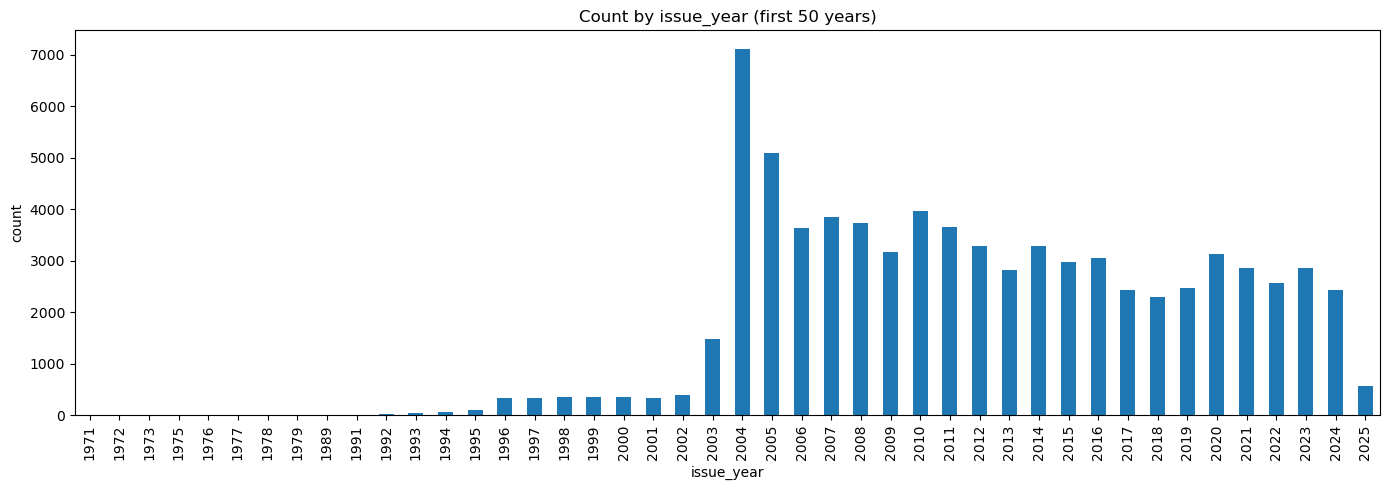

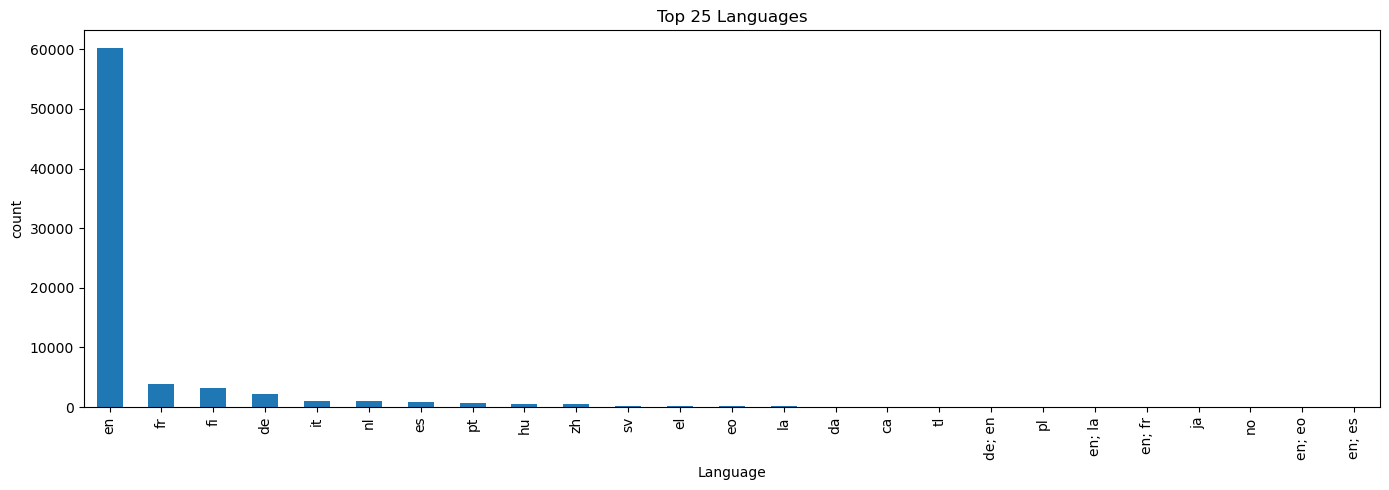

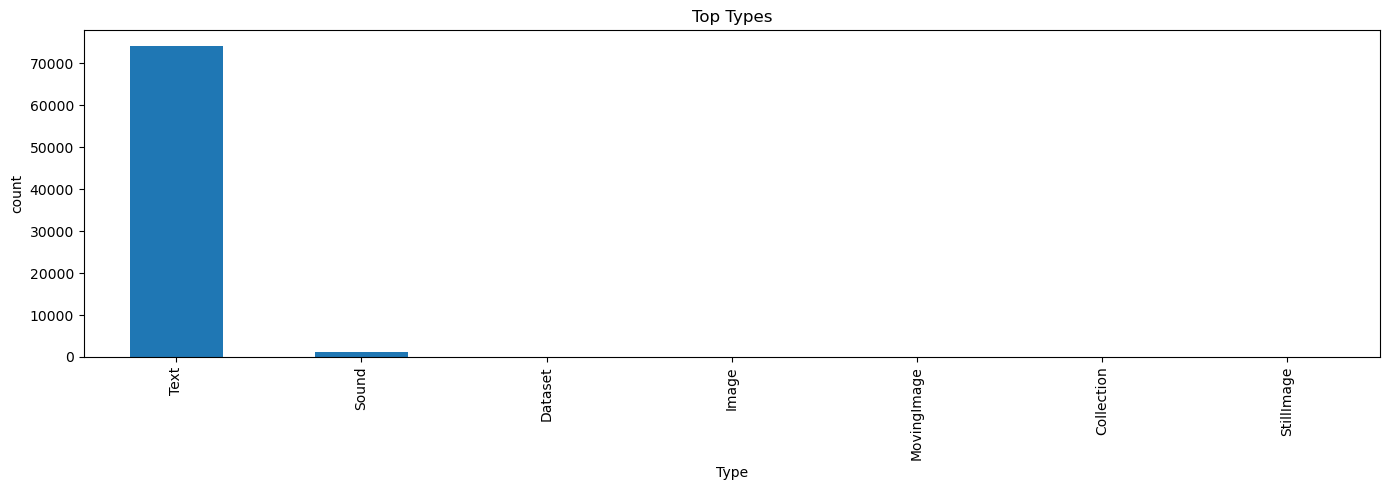

In [8]:
# Quick EDA summary for df_raw

# 1) Basic structure
print("shape:", df_raw.shape)
print("columns:", list(df_raw.columns))
print("\n--- dtypes ---")
print(df_raw.dtypes)

# 2) Peek at data
display(df_raw.head(10))
display(df_raw.tail(5))

# 3) Info + basic statistics
df_raw.info(memory_usage="deep")
display(df_raw.describe(include="all").T)

# 4) Missing values
missing = df_raw.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df_raw) * 100).round(2)
display(pd.DataFrame({"missing": missing, "missing_pct": missing_pct}))

# 5) Convert date column and derive year
df = df_raw.copy()
if "Issued" in df.columns:
    df["Issued"] = pd.to_datetime(df["Issued"], errors="coerce")
    print("Issued min/max:", df["Issued"].min(), df["Issued"].max())
    df["issue_year"] = df["Issued"].dt.year

# 6) Value counts for relevant columns
for col in ["Language", "Type", "LoCC", "Authors", "Bookshelves", "Etext Number", "Title"]:
    if col in df.columns:
        print(f"\nTop 20 values in {col}:")
        display(df[col].value_counts(dropna=False).head(20))

# 7) Numeric columns overview
numeric_cols = df.select_dtypes(include=["int64","float64"]).columns.tolist()
print("\nNumeric columns:", numeric_cols)
if numeric_cols:
    display(df[numeric_cols].describe().T)

# 8) Simple plots (matplotlib)
plt.figure(figsize=(14,5))
if "issue_year" in df.columns:
    df["issue_year"].dropna().astype(int).value_counts().sort_index().iloc[:50].plot(kind="bar")
    plt.title("Count by issue_year (first 50 years)")
    plt.xlabel("issue_year")
    plt.ylabel("count")
    plt.tight_layout()

plt.figure(figsize=(14,5))
if "Language" in df.columns:
    df["Language"].value_counts().head(25).plot(kind="bar")
    plt.title("Top 25 Languages")
    plt.xlabel("Language")
    plt.ylabel("count")
    plt.tight_layout()

plt.figure(figsize=(14,5))
if "Type" in df.columns:
    df["Type"].value_counts().head(25).plot(kind="bar")
    plt.title("Top Types")
    plt.xlabel("Type")
    plt.ylabel("count")
    plt.tight_layout()

# 9) Pairwise null-check for key columns
selected = ["Language", "Type", "LoCC", "Authors", "Bookshelves", "Issued"]
existing = [c for c in selected if c in df.columns]
display(df[existing].isna().mean().sort_values(ascending=False))

# 10) Save a small summary if desired
eda_summary = {
    "shape": df.shape,
    "missing": missing.to_dict(),
    "dtypes": df.dtypes.astype(str).to_dict(),
    "top_languages": df["Language"].value_counts().head(20).to_dict() if "Language" in df.columns else None,
}
print("EDA summary keys:", list(eda_summary.keys()))

In [17]:
with open(path + '/books/7', 'r') as file:
    content = file.read()
    print(content)

The Project Gutenberg eBook of The Mayflower Compact

This eBook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almost no restrictions
whatsoever. You may copy it, give it away or re-use it under the terms
of the Project Gutenberg License included with this eBook or online at
www.gutenberg.org. If you are not located in the United States, you
will have to check the laws of the country where you are located before
using this eBook.

Title: The Mayflower Compact

Release Date: December 31, 1977 [eBook #7]
[Most recently updated: December 14, 2023]

Language: English


*** START OF THE PROJECT GUTENBERG EBOOK THE MAYFLOWER COMPACT ***




The Mayflower Compact

November 11, 1620  [This was November 21, old style calendar]

In the name of God, Amen.  We, whose names are underwritten, the Loyal
Subjects of our dread Sovereigne Lord, King James, by the Grace of God,
of Great Britaine, France, and Ireland, King, Defender of the Fai

# Filter opium mention

This includes all phrases related to opium as itself, its derivatives, medical terms, and slangs

In [10]:
opium_keywords = [
    'opium', 'poppy', 'anodyne', 'laudanum', 'morphine', 'codein', 'heroin',
    'narcotic', 'soporific', 'paregoric', 'dover\u2019s powder', 'chandu',
    'nepenthe', 'dream-gum', 'dream-stick', 'black smoke'
]

Iterate through each 'Etext Number' in `df_raw`, read the content of each corresponding book, identify all occurrences of the defined `opium_keywords`, and store the 'Etext Number' along with the list of found 'Opium Keywords' in a new DataFrame.



In [11]:
opium_mentions = []
missing_book_files = []

for etext_number in tqdm(df_raw["Etext Number"].unique()):
    full_path = os.path.join(path, "books", str(etext_number))
    found_keywords = []
    try:
        with open(full_path, 'r', encoding='utf-8', errors='ignore') as file:
            content = file.read().lower() # Read content and convert to lowercase for case-insensitive matching
            for keyword in opium_keywords:
                if keyword in content:
                    found_keywords.append(keyword)

        if found_keywords: # Only add if at least one keyword is found
            opium_mentions.append({
                'Etext Number': etext_number,
                'Opium Keywords': list(set(found_keywords)) # Use set to get unique keywords
            })
    except FileNotFoundError:
        missing_book_files.append(etext_number)
    except Exception as e:
        print(f"Error processing Etext Number {etext_number}: {e}")

opium_mentions_df = pd.DataFrame(opium_mentions)

print(f"\nFound {len(opium_mentions_df)} books with opium-related keywords.")
print(f"Skipped {len(missing_book_files)} books due to missing files.")
print("\nHead of the new DataFrame:")
display(opium_mentions_df.head())

  0%|          | 0/75394 [00:00<?, ?it/s]


Found 24498 books with opium-related keywords.
Skipped 24 books due to missing files.

Head of the new DataFrame:


,Etext Number,Opium Keywords
0,14,"[morphine, heroin, opium, codein, paregoric, n..."
1,15,"[opium, paregoric, laudanum]"
2,16,[heroin]
3,22,"[morphine, heroin, anodyne, opium, laudanum, p..."
4,24,[poppy]


In [12]:
# Merge with the metadata earlier
df_merged = pd.merge(df_raw, opium_mentions_df, on='Etext Number', how='right')

print("Shape of the merged DataFrame:", df_merged.shape)
print("\nHead of the merged DataFrame:")
display(df_merged.head())

Shape of the merged DataFrame: (24498, 22)

Head of the merged DataFrame:


,Etext Number,Type,Issued,Title,Language,LoCC,Bookshelves,Authors,rights,Subjects,...,EPUB (older E-readers),"EPUB (no images, older E-readers)",Kindle,Kindle (E-readers incl. Send-to-Kindle),"Kindle (no images, older E-readers)",Plain Text UTF-8,Download HTML(zip),Resource Description Framework (RDF),Other Links,Opium Keywords
0,14,Text,1991-04-01,The 1990 CIA World Factbook,en,G,CIA World Factbooks; Browsing: Encyclopedias/D...,United States. Central Intelligence Agency,Public domain in the USA.,"Political statistics -- Handbooks, manuals, et...",...,https://www.gutenberg.org/ebooks/14.epub.images,https://www.gutenberg.org/ebooks/14.epub.noimages,https://www.gutenberg.org/ebooks/14.kf8.images,https://www.gutenberg.org/ebooks/14.kindle.images,https://www.gutenberg.org/ebooks/14.kindle.noi...,https://www.gutenberg.org/ebooks/14.txt.utf-8,https://www.gutenberg.org/cache/epub/14/pg14-h...,https://www.gutenberg.org/ebooks/14.rdf,https://www.gutenberg.org/cache/epub/14/pg14.c...,"[morphine, heroin, opium, codein, paregoric, n..."
1,15,Text,1991-05-01,"Moby-Dick; or, The Whale",en,PS,Adventure; Best Books Ever Listings; Browsing:...,"Melville, Herman",Public domain in the USA.,"Whales -- Fiction ; Ahab, Captain (Fictitious ...",...,https://www.gutenberg.org/ebooks/15.epub.images,https://www.gutenberg.org/ebooks/15.epub.noimages,https://www.gutenberg.org/ebooks/15.kf8.images,https://www.gutenberg.org/ebooks/15.kindle.images,https://www.gutenberg.org/ebooks/15.kindle.noi...,https://www.gutenberg.org/ebooks/15.txt.utf-8,https://www.gutenberg.org/cache/epub/15/pg15-h...,https://www.gutenberg.org/ebooks/15.rdf,https://www.gutenberg.org/files/15/15-h/15-h.h...,"[opium, paregoric, laudanum]"
2,16,Text,2008-06-25,Peter Pan,en,PR; PZ,Children's Literature; Movie Books; Browsing: ...,"Barrie, J. M. (James Matthew)",Public domain in the USA.,Peter Pan (Fictitious character) -- Fiction ; ...,...,https://www.gutenberg.org/ebooks/16.epub.images,https://www.gutenberg.org/ebooks/16.epub.noimages,https://www.gutenberg.org/ebooks/16.kf8.images,https://www.gutenberg.org/ebooks/16.kindle.images,https://www.gutenberg.org/ebooks/16.kindle.noi...,https://www.gutenberg.org/ebooks/16.txt.utf-8,https://www.gutenberg.org/files/16/16-h.zip,https://www.gutenberg.org/ebooks/16.rdf,https://www.gutenberg.org/cache/epub/16/pg16.c...,[heroin]
3,22,Text,1991-12-01,Roget's Thesaurus,en,PE,Reference; Browsing: Encyclopedias/Dictionarie...,"Roget, Peter Mark",Public domain in the USA.,English language -- Synonyms and antonyms ; PE,...,https://www.gutenberg.org/ebooks/22.epub.images,https://www.gutenberg.org/ebooks/22.epub.noimages,https://www.gutenberg.org/ebooks/22.kf8.images,https://www.gutenberg.org/ebooks/22.kindle.images,https://www.gutenberg.org/ebooks/22.kindle.noi...,https://www.gutenberg.org/ebooks/22.txt.utf-8,https://www.gutenberg.org/files/22/22-h.zip,https://www.gutenberg.org/ebooks/22.rdf,https://www.gutenberg.org/cache/epub/22/pg22.c...,"[morphine, heroin, anodyne, opium, laudanum, p..."
4,24,Text,2008-06-27,O Pioneers!,en,PS,Browsing: Culture/Civilization/Society; Browsi...,"Cather, Willa",Public domain in the USA.,Swedish Americans -- Fiction ; Frontier and pi...,...,https://www.gutenberg.org/ebooks/24.epub.images,https://www.gutenberg.org/ebooks/24.epub.noimages,https://www.gutenberg.org/ebooks/24.kf8.images,https://www.gutenberg.org/ebooks/24.kindle.images,https://www.gutenberg.org/ebooks/24.kindle.noi...,https://www.gutenberg.org/ebooks/24.txt.utf-8,https://www.gutenberg.org/files/24/24-h.zip,https://www.gutenberg.org/ebooks/24.rdf,https://www.gutenberg.org/files/24/24-0.zip ; ...,[poppy]


In [13]:
df_merged.to_csv("../../data/GP_opium.csv", index=False)

In [16]:
output_dir = '../opium_books_fulltext'
os.makedirs(output_dir, exist_ok=True)
print(f"Created output directory: {output_dir}")

# Copy selected book files to the output directory
copied_files_count = 0
for etext_number in tqdm(df_merged['Etext Number']):
    source_file_path = os.path.join(path, "books", str(etext_number))
    destination_file_path = os.path.join(output_dir, str(etext_number))
    try:
        shutil.copyfile(source_file_path, destination_file_path)
        copied_files_count += 1
    except FileNotFoundError:
        print(f"Warning: Source file not found for Etext Number {etext_number}. Skipping.")
    except Exception as e:
        print(f"Error copying file for Etext Number {etext_number}: {e}")

print(f"Copied {copied_files_count} book files to '{output_dir}'.")

# Compress the output directory into a zip file
zip_file_name = 'opium_books_fulltext'
zip_file_path = shutil.make_archive(zip_file_name, 'zip', output_dir)

print(f"\nSuccessfully created zip file: {zip_file_path}")

Created output directory: ../opium_books_fulltext


  0%|          | 0/24498 [00:00<?, ?it/s]

Copied 24498 book files to '../opium_books_fulltext'.

Successfully created zip file: /Users/ngocdoan/EPFL/M3/history n digital/opium-gutenberg/code/opium_books_fulltext.zip


In [17]:
#Clears kaggle cache on your machine, but you will need to reload the dataset next time
DELETE_KAGGELHUB_CACHE = False

if DELETE_KAGGELHUB_CACHE:
    # KaggleHub stores datasets here by default
    cache_path = os.path.expanduser("~/.cache/kagglehub/datasets/lokeshparab/gutenberg-books-and-metadata-2025")
    shutil.rmtree(cache_path)
    print("Deleted!")